*TASK5_WEEK2_Data visualisation*

# Employee Satisfaction Survey Data Analysis

## Step 1 : Required framework and data importing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('emp_attrition.csv')
df

,Emp ID,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,dept,salary
0,1.0,0.38,0.53,2.0,157.0,3.0,0.0,0.0,sales,low
1,2.0,0.80,0.86,5.0,262.0,6.0,0.0,0.0,sales,medium
2,3.0,0.11,0.88,7.0,272.0,4.0,0.0,0.0,sales,medium
3,4.0,0.72,0.87,5.0,223.0,5.0,0.0,0.0,sales,low
4,5.0,0.37,0.52,2.0,159.0,3.0,0.0,0.0,sales,low
...,...,...,...,...,...,...,...,...,...,...
15782,14995.0,0.40,0.57,2.0,151.0,3.0,0.0,0.0,support,low
15783,14996.0,0.37,0.48,2.0,160.0,3.0,0.0,0.0,support,low
15784,14997.0,0.37,0.53,2.0,143.0,3.0,0.0,0.0,support,low
15785,14998.0,0.11,0.96,6.0,280.0,4.0,0.0,0.0,support,low


In [3]:
df.shape

(15787, 10)

## Step 2 : Data Cleaning and Preprocessing

In [4]:
df.isnull().sum()

Emp ID                   788
satisfaction_level       788
last_evaluation          788
number_project           788
average_montly_hours     788
time_spend_company       788
Work_accident            788
promotion_last_5years    788
dept                     788
salary                   788
dtype: int64

In [5]:
df[df.isna().any(axis=1)]

,Emp ID,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,dept,salary
12783,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12784,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12785,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12786,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12787,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
13566,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13568,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13569,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df=df.drop(df[df.isna().any(axis=1)].index)

In [7]:
df

,Emp ID,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,dept,salary
0,1.0,0.38,0.53,2.0,157.0,3.0,0.0,0.0,sales,low
1,2.0,0.80,0.86,5.0,262.0,6.0,0.0,0.0,sales,medium
2,3.0,0.11,0.88,7.0,272.0,4.0,0.0,0.0,sales,medium
3,4.0,0.72,0.87,5.0,223.0,5.0,0.0,0.0,sales,low
4,5.0,0.37,0.52,2.0,159.0,3.0,0.0,0.0,sales,low
...,...,...,...,...,...,...,...,...,...,...
15782,14995.0,0.40,0.57,2.0,151.0,3.0,0.0,0.0,support,low
15783,14996.0,0.37,0.48,2.0,160.0,3.0,0.0,0.0,support,low
15784,14997.0,0.37,0.53,2.0,143.0,3.0,0.0,0.0,support,low
15785,14998.0,0.11,0.96,6.0,280.0,4.0,0.0,0.0,support,low


In [8]:
df=df.reset_index(drop=True)

In [9]:
df.shape

(14999, 10)

In [10]:
df.duplicated().sum()

0

In [11]:
df.isnull().sum()

Emp ID                   0
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
promotion_last_5years    0
dept                     0
salary                   0
dtype: int64

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Emp ID                 14999 non-null  float64
 1   satisfaction_level     14999 non-null  float64
 2   last_evaluation        14999 non-null  float64
 3   number_project         14999 non-null  float64
 4   average_montly_hours   14999 non-null  float64
 5   time_spend_company     14999 non-null  float64
 6   Work_accident          14999 non-null  float64
 7   promotion_last_5years  14999 non-null  float64
 8   dept                   14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(8), object(2)
memory usage: 1.1+ MB


In [13]:
df.describe()

,Emp ID,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,7500.000000,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.021268
std,4329.982679,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.144281
min,1.000000,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000
25%,3750.500000,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000
50%,7500.000000,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000
75%,11249.500000,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000
max,14999.000000,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000


In [14]:
df.dtypes

Emp ID                   float64
satisfaction_level       float64
last_evaluation          float64
number_project           float64
average_montly_hours     float64
time_spend_company       float64
Work_accident            float64
promotion_last_5years    float64
dept                      object
salary                    object
dtype: object

In [15]:
int_cols=["number_project","average_montly_hours","time_spend_company","Work_accident","promotion_last_5years"]
for i in int_cols:
    df[i]=df[i].astype(int)

In [16]:
df.dtypes

Emp ID                   float64
satisfaction_level       float64
last_evaluation          float64
number_project             int32
average_montly_hours       int32
time_spend_company         int32
Work_accident              int32
promotion_last_5years      int32
dept                      object
salary                    object
dtype: object

## Step 3 : Exploratory data analysis

### univariate analysis

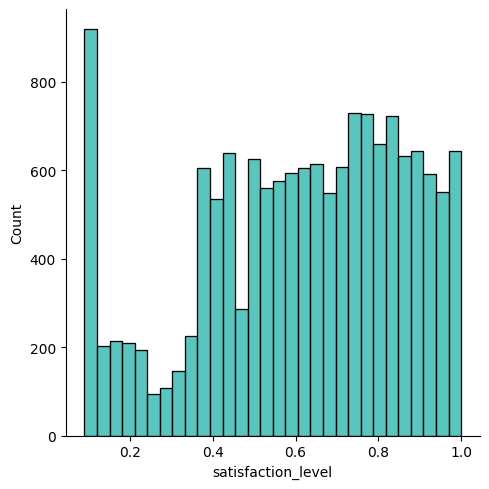

In [17]:
sns.displot(df['satisfaction_level'],color='lightseagreen')
plt.show()

In [18]:
df['satisfaction_level'].value_counts()

satisfaction_level
0.10    358
0.11    335
0.74    257
0.77    252
0.84    247
       ... 
0.25     34
0.28     31
0.27     30
0.26     30
0.12     30
Name: count, Length: 92, dtype: int64

* 0.09 is the lowest and 1.0 is the highest satisfaction level recorded.
* 0.1 and 0.11 is the lowest satisfaction level value with highest number of occurence.
* Most of the people have a satisfaction level greater than 0.5

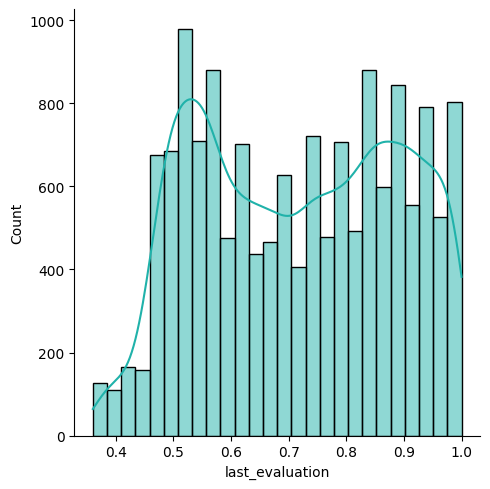

In [19]:
sns.displot(df["last_evaluation"],kde=True,color='lightseagreen')
plt.show()

* 0.3 is the minimum and 1.0 is the maximum in 'last_evaluation' score
* Highest number of employees acquired their last work evaluation score around 0.5 and 0.85

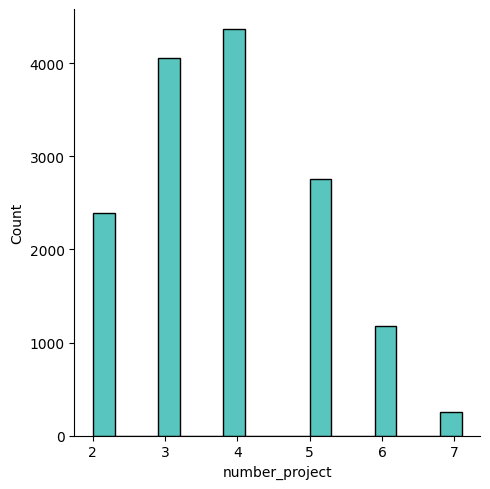

In [20]:
sns.displot(df["number_project"],binwidth=.3,color='lightseagreen')
plt.show()

* More than 4000 employees among 14999 employees completed 3 or 4 projects
* The number of employes who has completed atleast 7 projects is less than 500

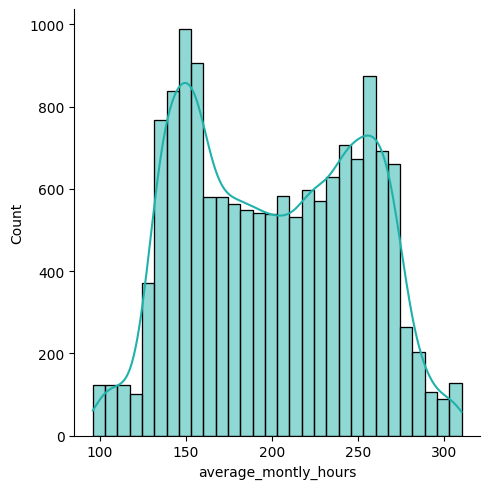

In [21]:
sns.displot(df["average_montly_hours"],kde=True,color='lightseagreen')
plt.show()

* Number of employees who give around 150 or around 260 hours per month is high

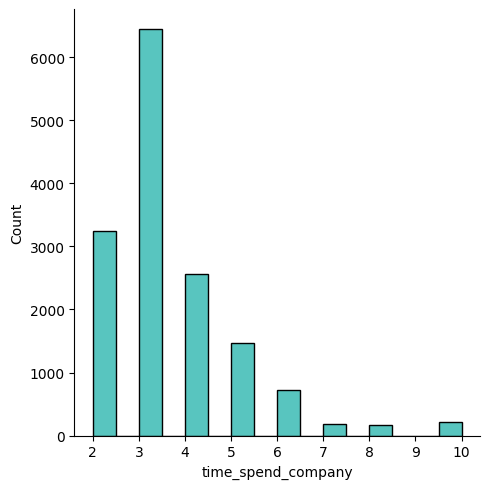

In [22]:
sns.displot(df["time_spend_company"],binwidth=0.5,color='lightseagreen')
plt.show()

* Majority of the employees spent 3 years in company.
* Senior employees, who have spent more than 6 years in company are less than 600

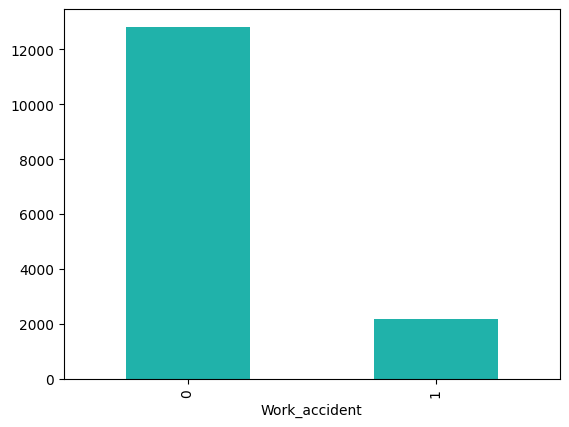

In [23]:
df["Work_accident"].value_counts().plot(kind="bar",color='lightseagreen')
plt.show()

* More than 12000 employees done "NO" work accidents
* Around 2000 employees have done work accidents

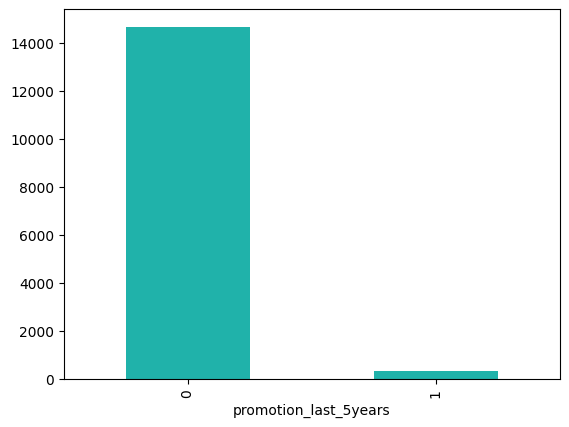

In [24]:
df["promotion_last_5years"].value_counts().plot(kind="bar",color='lightseagreen')
plt.show()

* Only very few employees (less than 500) eceived a promotion in their career

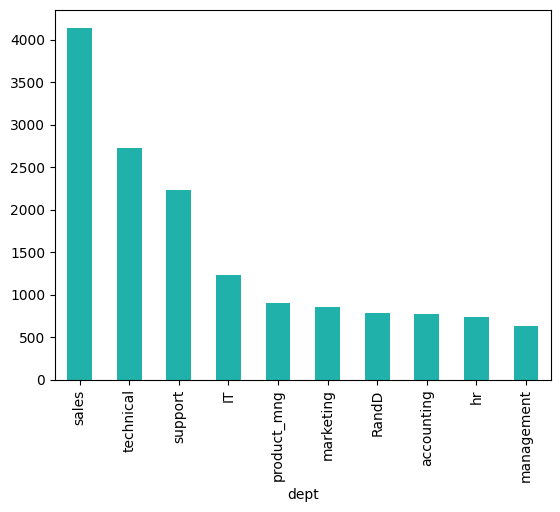

In [25]:
df["dept"].value_counts().plot(kind="bar",color='lightseagreen')
plt.show()

* Highest number of employees are from sales department and leas numbers are from management

In [26]:
df["salary"].value_counts()

salary
low       7316
medium    6446
high      1237
Name: count, dtype: int64

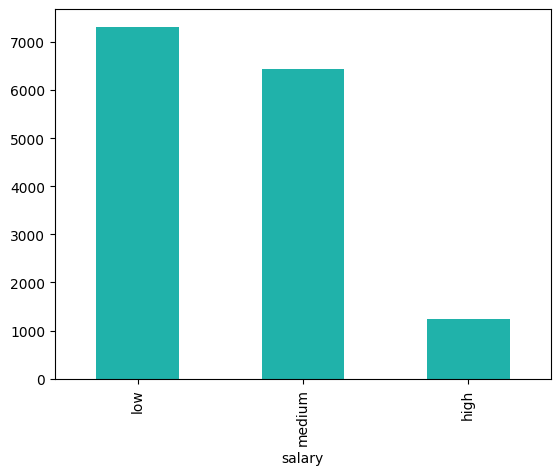

In [27]:
df["salary"].value_counts().plot(kind="bar",color='lightseagreen')
plt.show()

* More than 50% of the employees get low salary.
* Less than 10% of the employees get a high salary.

### Bivariate analysis

# Q1: what are the factors that affects satisfaction value of employees?

In [28]:
df_low_sat=df[df["satisfaction_level"]<0.2]
df_high_sat=df[df["satisfaction_level"]>0.9]

In [29]:
df_low_sat.shape

(1409, 10)

In [30]:
df_high_sat.shape

(1784, 10)

Left side charts shows lower satisfaction & Right side charts shows higher satisfaction


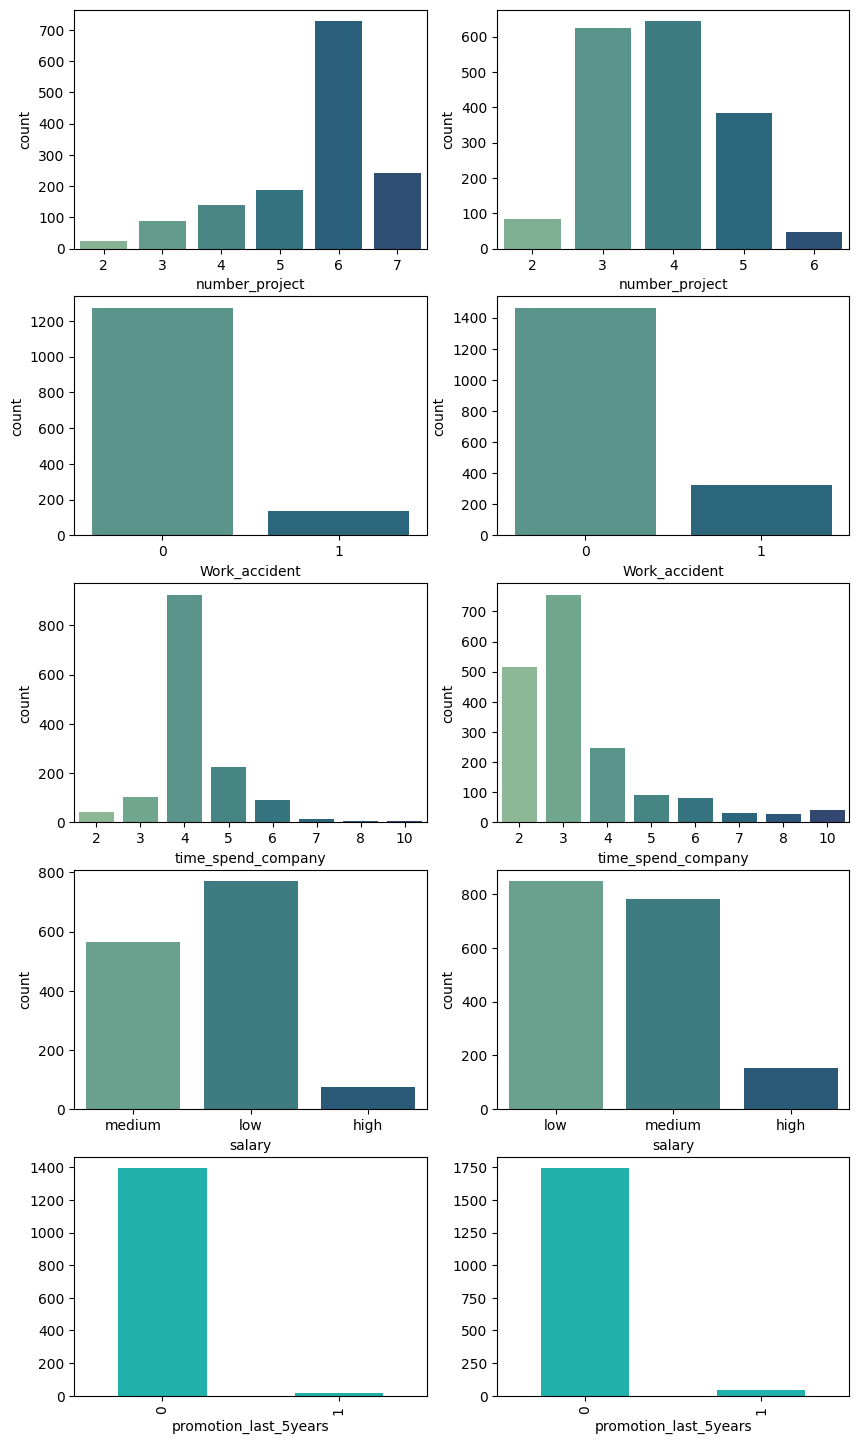

In [31]:
plt.figure(figsize=(10,18))
print("Left side charts shows lower satisfaction & Right side charts shows higher satisfaction")
plt.subplot(5,2,1)
sns.countplot(data=df_low_sat, x=df_low_sat["number_project"],palette='crest')
plt.subplot(5,2,2)
sns.countplot(data=df_high_sat, x=df_high_sat["number_project"],palette='crest')
plt.subplot(5,2,3)
sns.countplot(data=df_low_sat, x=df_low_sat["Work_accident"],palette='crest')
plt.subplot(5,2,4)
sns.countplot(data=df_high_sat, x=df_high_sat["Work_accident"],palette='crest')
plt.subplot(5,2,5)
sns.countplot(data=df_low_sat, x=df_low_sat["time_spend_company"],palette='crest')
plt.subplot(5,2,6)
sns.countplot(data=df_high_sat,x=df_high_sat["time_spend_company"],palette='crest')
plt.subplot(5,2,7)
sns.countplot(data=df_low_sat,x=df_low_sat["salary"],palette='crest')
plt.subplot(5,2,8)
sns.countplot(data=df_high_sat,x=df_high_sat["salary"],palette='crest')
plt.subplot(5,2,9)
df_low_sat["promotion_last_5years"].value_counts().plot(kind='bar',color='lightseagreen')
plt.subplot(5,2,10)
df_high_sat["promotion_last_5years"].value_counts().plot(kind='bar',color='lightseagreen')
plt.show()

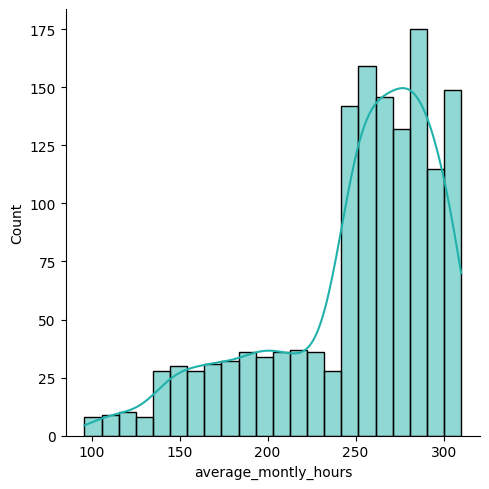

In [32]:
sns.displot(data=df_low_sat["average_montly_hours"],kde=True,color='lightseagreen')

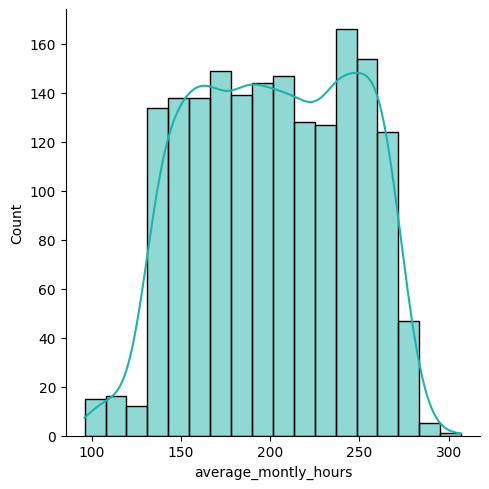

In [33]:
sns.displot(data=df_high_sat["average_montly_hours"],kde=True,color='lightseagreen')

In [34]:
print(df_low_sat["average_montly_hours"].mean())
print(df_high_sat["average_montly_hours"].mean())

250.17601135557132
201.96804932735427


### Reasons for lower satisfaction rate
* Employees who gives a lower satisfaction rate, majority of them has to work on 6 or 7 projects currently. Where employees with high satisfaction rate, majority of them has to work on only 3 or 4 projects currently.
* In high satisfaction rate category, there are employees who have done more work accidents and In lower satisfaction category, there are employees with lower work accidents.
* Number of employees with more than 5 years of work experience is higher in category with high satisfaction rate than category with lower satisfaction rate.
* Around 580 employees get a medium and less than 100 employees get a high salary in lower satisfaction category. where around 780 employees get a medium and more than 100 employees get high salary in higher satisfaction category
* Since the number of experienced people are high in  higher satisfaction category, the number of employees who got promotion in the last 5 years is high in this category.
* The average monthly working time of people who are in lower satisfaction category is 250. where in higher satisfaction category is 201

* low salary,low promotion, high working hours and more projects to handle make the employees satisfaction rate to GO DOWN 

# Q2: Analyse the salary data distribution in each department

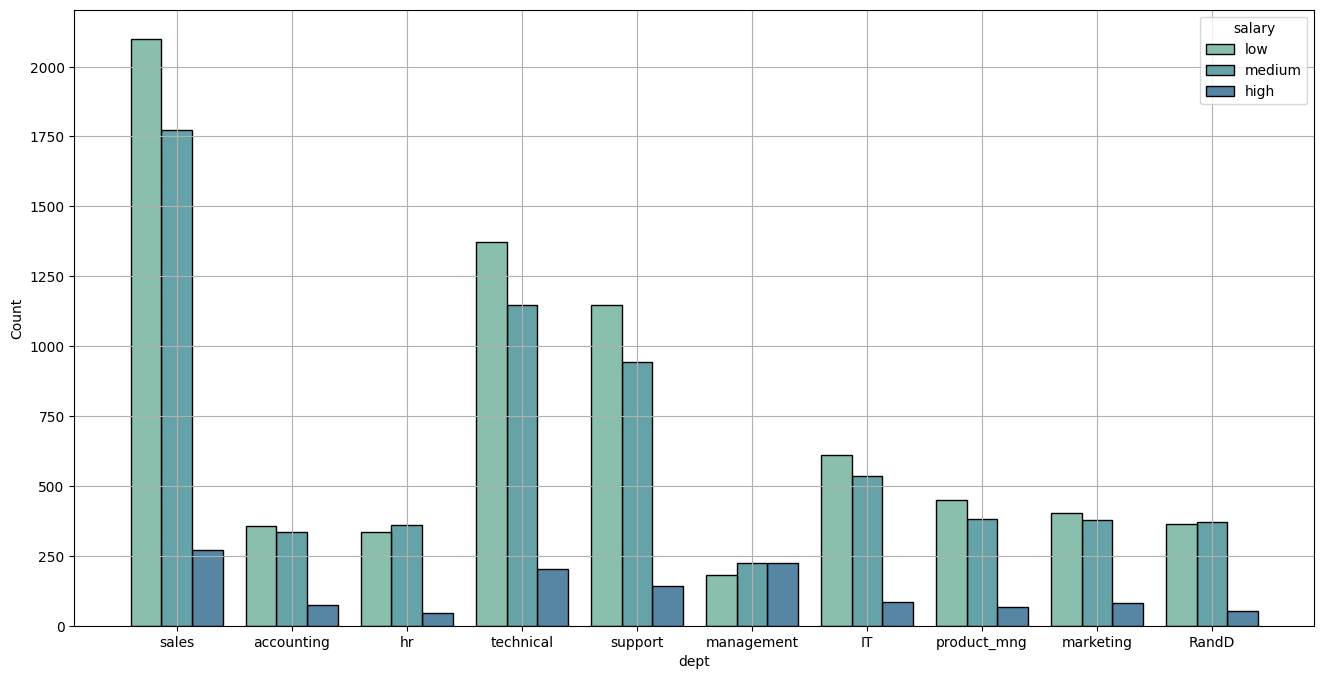

In [35]:
plt.figure(figsize=(16,8))
sns.histplot(x="dept",hue="salary",data=df,palette="crest",multiple="dodge",stat="count",shrink=0.8)
plt.grid()
plt.show()

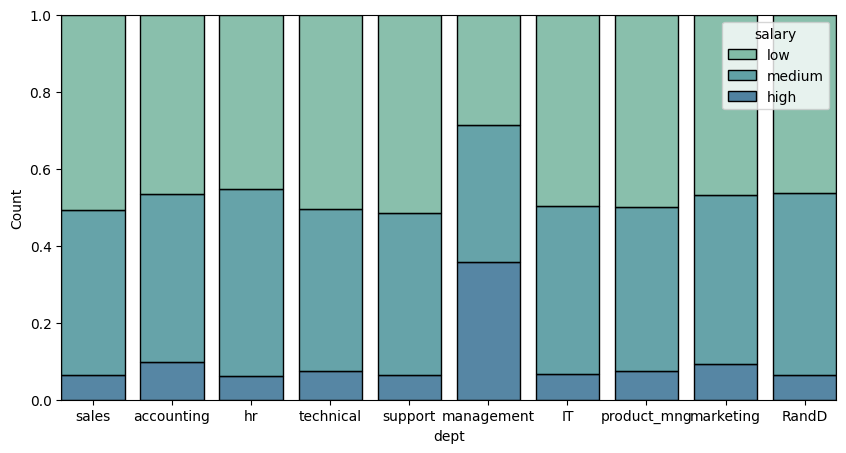

In [36]:
plt.figure(figsize=(10,5))
sns.histplot(x="dept",hue="salary",data=df,palette="crest",multiple="fill",stat="count",shrink=0.8)
plt.show()

* The highest number of 'high salary' employees are in sales, management and technical departments
* The least number of 'high salary' employees are in hr and RandD departments.
* But when we take the percentage, all departments except management department, the employees who get a high salary is less than 10%. Where around 36% of employees from management department gets high salary.

# Q3: Which are the factors that affect salary lowering?

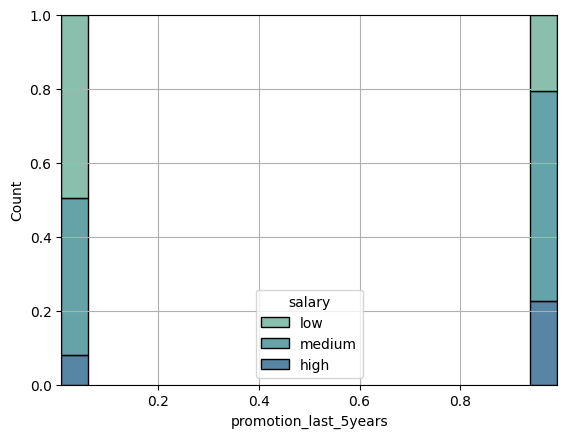

In [37]:
sns.histplot(x="promotion_last_5years",hue="salary",data=df,palette="crest",multiple="fill",stat="count",shrink=0.8)
plt.grid()
plt.show()

* Around 22% of the employees getting high salary and around 20% of the employees are getting low salary among the employees with promotion.
* Only less than 10% of the employees getting high salary and around 50% of the employees are getting low salary among the employees with NO promotion.

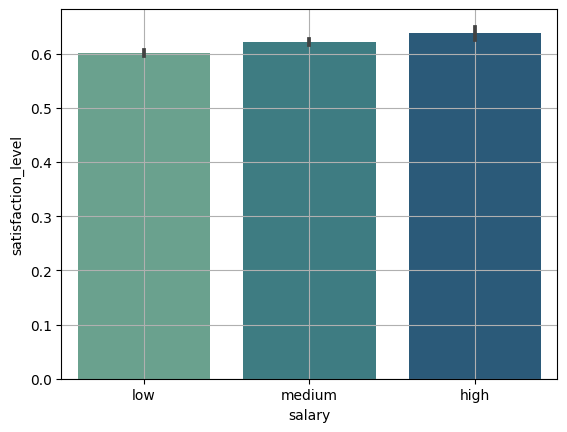

In [38]:
sns.barplot(x="salary",y="satisfaction_level",estimator="mean",data=df,palette="crest")
plt.grid()

* There is an increment in satisfaction level according to increment in salary range

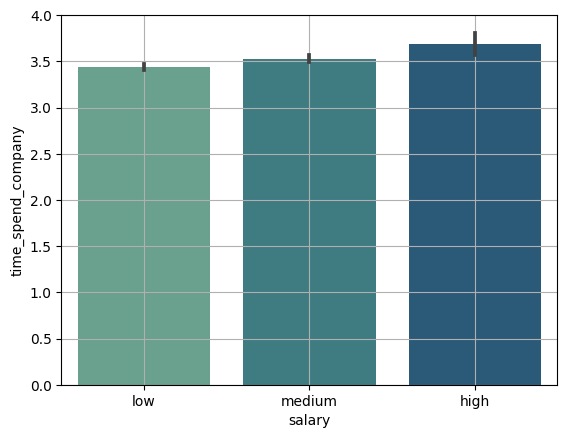

In [39]:
sns.barplot(x="salary",y="time_spend_company",estimator='mean',data=df,palette="crest")
plt.grid()

* Work experience and salary shows positive linear relation.
* In this graph the average work experience of employees with low, medium and high salaries are given.

# Q4: What are the factors that affect promotion?

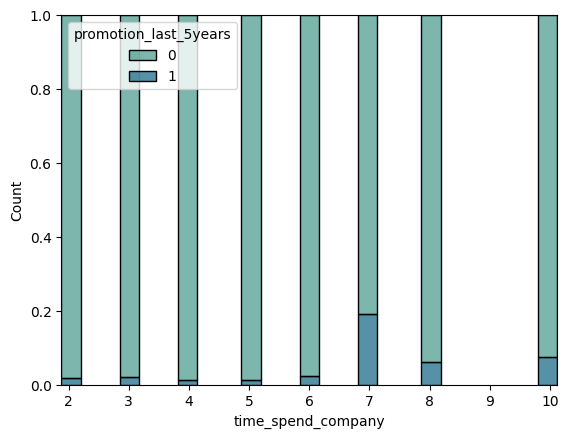

In [40]:
sns.histplot(hue="promotion_last_5years",x="time_spend_company",data=df,palette="crest",multiple="fill",stat="count",shrink=4)
plt.show()

* Employees with 7 or 8 or 10 years of experience has more chances of getting a promotion.

In [41]:
promo_yes=df[df["promotion_last_5years"]==1]
promo_no=df[df["promotion_last_5years"]==0]

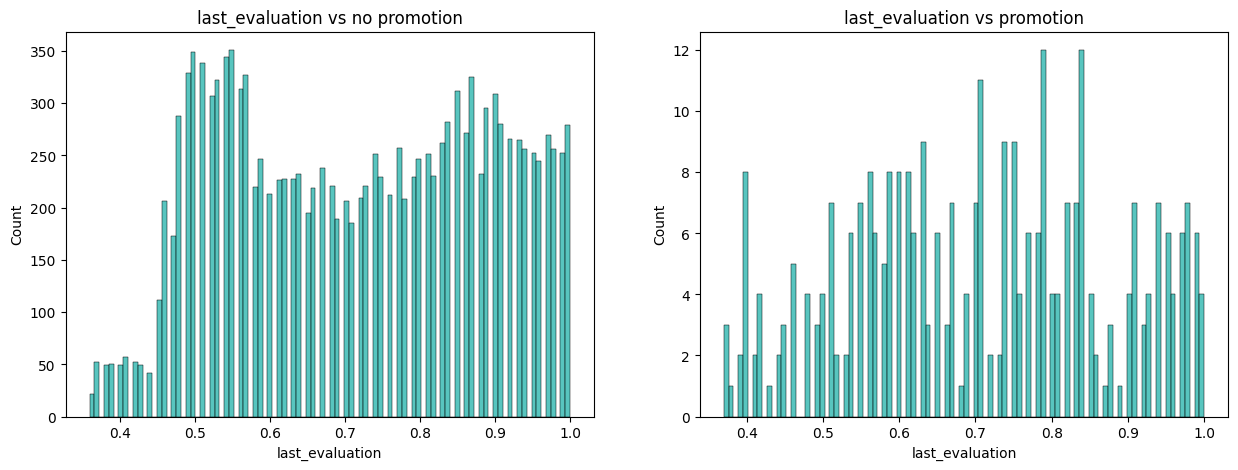

In [42]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,2)
sns.histplot(promo_yes["last_evaluation"],bins=100,color='lightseagreen').set(title='last_evaluation vs promotion')
plt.subplot(1,2,1)
sns.histplot(promo_no["last_evaluation"],bins=100,color='lightseagreen').set(title='last_evaluation vs no promotion')
plt.show()

* The mode value of last_evalution for the people who dont have promotion is around 0.55 where the mode value of last_evalution for the people who have promotion is around 0.8

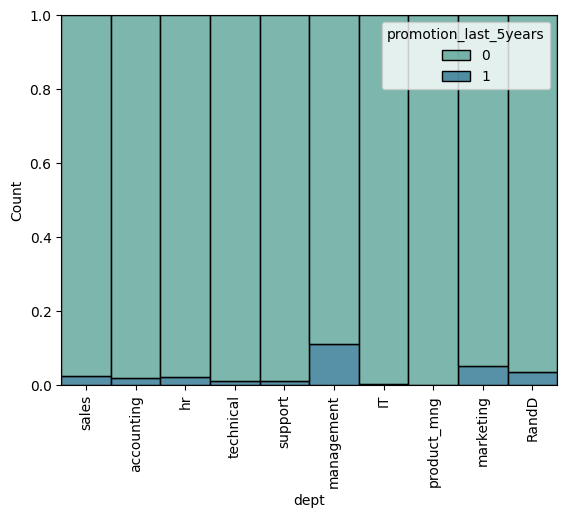

In [43]:
plt.xticks(rotation=90)
sns.histplot(hue="promotion_last_5years",x="dept",data=df,palette="crest",multiple="fill",stat="count",shrink=1)
plt.show()

* The chances of a promotion for the employees in management department is higher than employees in other department

## Step 4 : Outlier and correlation detection

<Axes: >

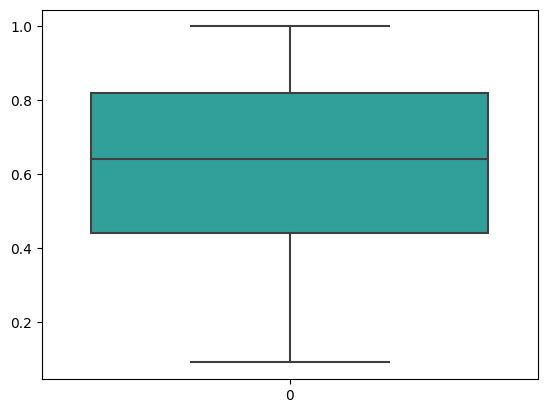

In [44]:
sns.boxplot(df['satisfaction_level'],color='lightseagreen')

<Axes: >

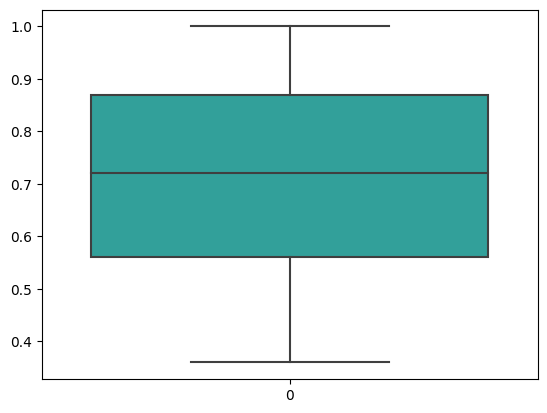

In [45]:
sns.boxplot(df['last_evaluation'],color='lightseagreen')

* There is no outliers in the 2 columns with continuous numerical values

In [46]:
df_new=df.drop('dept',axis=1)

In [47]:
df_new=df_new.replace({'salary':{"low":0,"medium":1,"high":2}})

In [48]:
df_new

,Emp ID,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,salary
0,1.0,0.38,0.53,2,157,3,0,0,0
1,2.0,0.80,0.86,5,262,6,0,0,1
2,3.0,0.11,0.88,7,272,4,0,0,1
3,4.0,0.72,0.87,5,223,5,0,0,0
4,5.0,0.37,0.52,2,159,3,0,0,0
...,...,...,...,...,...,...,...,...,...
14994,14995.0,0.40,0.57,2,151,3,0,0,0
14995,14996.0,0.37,0.48,2,160,3,0,0,0
14996,14997.0,0.37,0.53,2,143,3,0,0,0
14997,14998.0,0.11,0.96,6,280,4,0,0,0


<Axes: >

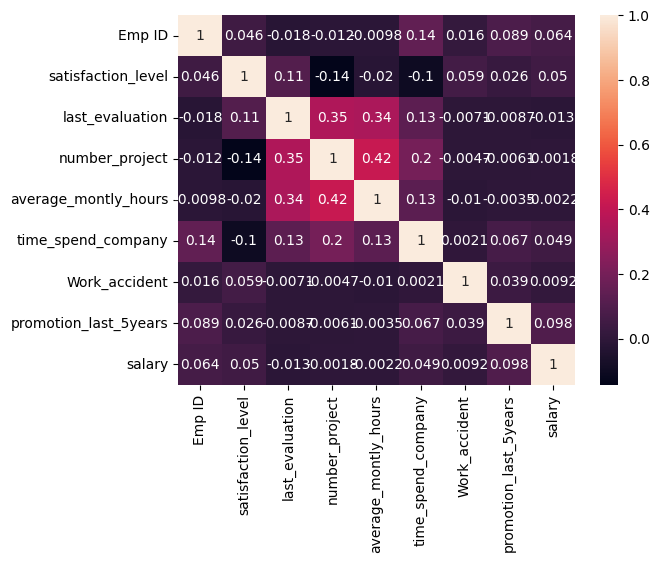

In [49]:
sns.heatmap(df_new.corr(),annot=True)

* Average monthly hours and number_project shows a positive correlation

*Thank you* 